In [72]:
import numpy as np
import scipy.stats as scs
import matplotlib.pyplot as plt
import sklearn.gaussian_process 
import pandas as pd
import sklearn

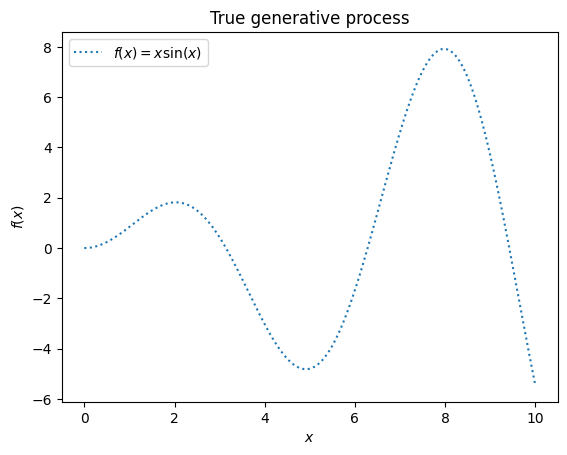

In [87]:
X = np.linspace(start=0, stop=10, num=1_000).reshape(-1, 1)
y = np.squeeze(X * np.sin(X))
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("True generative process")

In [88]:
rng = np.random.RandomState(1)
training_indices = rng.choice(np.arange(y.size), size=6, replace=False)
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor()
gaussian_process.fit(X_train, y_train)

,kernel,None
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,False
,copy_X_train,True
,n_targets,None
,random_state,None


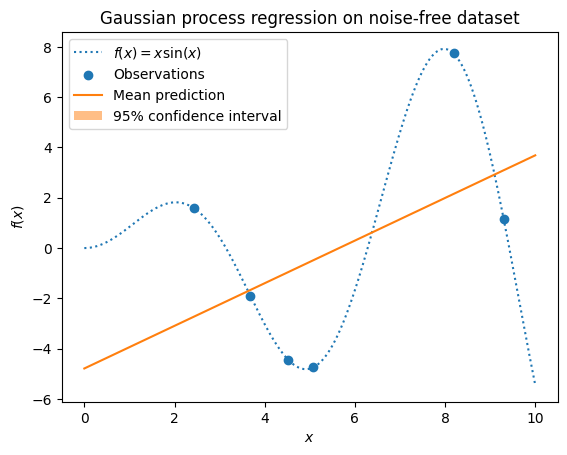

In [89]:
from sklearn.gaussian_process.kernels import DotProduct
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(kernel=DotProduct())
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
# preds.append(mean_prediction)
plt.plot(X, y, label=r"$f(x) = x \sin(x)$", linestyle="dotted")
plt.scatter(X_train, y_train, label="Observations")
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_prediction,
    mean_prediction + 1.96 * std_prediction,
    alpha=0.5,
    label=r"95% confidence interval",
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noise-free dataset")

In [90]:
sigma = 1
d = 1
np.random.seed(2)
w = np.random.randn(d)
eps = scs.norm.rvs(loc=0, scale=sigma, size=X.shape[0])
y = np.dot(X, w) + eps
training_indices = np.random.choice(np.arange(y.size), size=6, replace=False)

c:\Users\gusca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:305: RuntimeWarning: divide by zero encountered in log
  return np.log(np.hstack(theta))
c:\Users\gusca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter sigma_0 is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


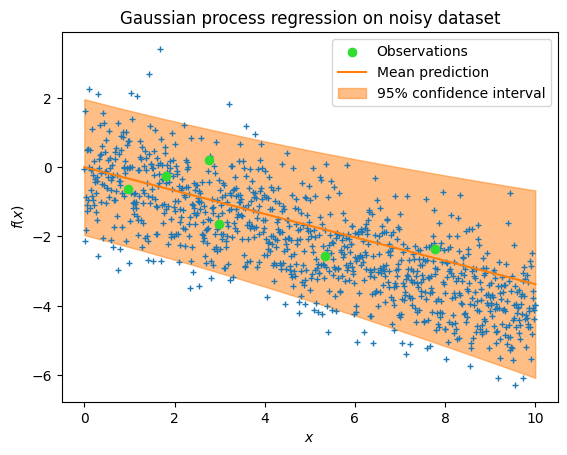

In [91]:
from sklearn.gaussian_process.kernels import DotProduct
X_train, y_train = X[training_indices], y[training_indices]
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(kernel=DotProduct(sigma_0=0), alpha=sigma**2)
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X, return_std=True)
std_pred_bruitee = np.sqrt(std_prediction**2 + sigma**2)
# preds.append(mean_prediction)
plt.plot(X, y, linestyle="", marker="+", markersize=4)
plt.scatter(X_train, y_train, label="Observations", color="#30DD30", zorder=3)
plt.plot(X, mean_prediction, label="Mean prediction")
plt.fill_between(
    X.ravel(),
    mean_prediction - 1.96 * std_pred_bruitee,
    mean_prediction + 1.96 * std_pred_bruitee,
    alpha=0.5,
    label=r"95% confidence interval",
    color="C1",
    
)
plt.legend()
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
_ = plt.title("Gaussian process regression on noisy dataset")

In [135]:
df = pd.read_csv("./data/airfoil_self_noise.dat", sep="\t", header=None, names=["Frequency", "Angle of attack", "Chord length", "Free-stream velocity", "Suction side displacement thickness", "Scaled sound pressure level"])

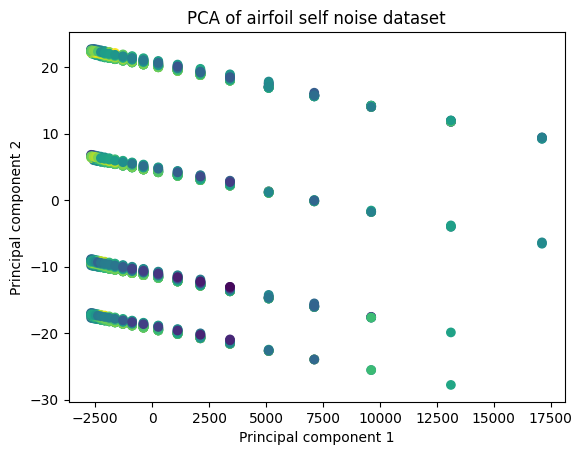

In [136]:
n_comp = 2
from sklearn.decomposition import PCA
pca = PCA(n_components=n_comp)
X = df.drop(columns="Scaled sound pressure level").values
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Scaled sound pressure level"], cmap="viridis")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
_ = plt.title("PCA of airfoil self noise dataset")

In [137]:
pca.components_

array([[ 9.99999651e-01, -5.12044691e-04, -1.08600785e-07,
         6.60275165e-04, -9.59842006e-07],
       [-6.37898573e-04,  4.25336414e-02, -2.38450600e-05,
         9.99094831e-01,  3.25549990e-05]])

In [138]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
n_comp=2
def pipeline_pca(n_comp):

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=n_comp))
    ])
    return pipeline

X_pca = pipeline_pca(2).fit_transform(X)

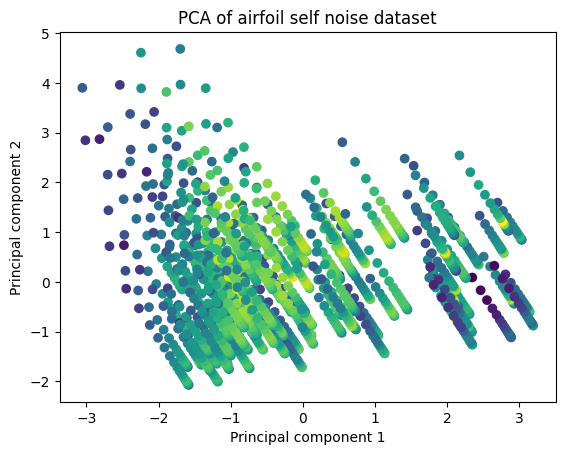

In [139]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["Scaled sound pressure level"], cmap="viridis")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
_ = plt.title("PCA of airfoil self noise dataset")

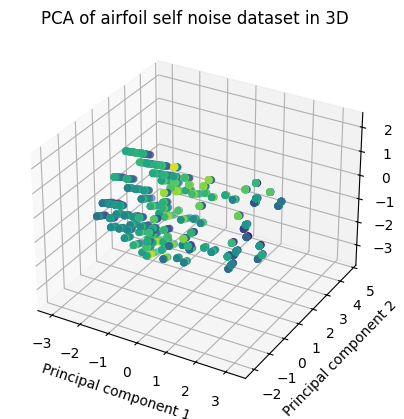

In [140]:
n_comp = 3
X_pca = pipeline_pca(3).fit_transform(X)
# on fait un plot 3d
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df["Scaled sound pressure level"], cmap="viridis")
ax.set_xlabel("Principal component 1")
ax.set_ylabel("Principal component 2")
ax.set_zlabel("Principal component 3")
_ = plt.title("PCA of airfoil self noise dataset in 3D")


In [142]:
# on normalise X
scaler = StandardScaler()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, df["Scaled sound pressure level"], test_size=0.2, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


(34, 5)

560     130.567
618     128.338
1405    119.350
1404    119.190
1403    119.040
576     124.647
578     119.137
621     120.228
558     132.127
1358    129.653
579     117.137
1353    133.023
1402    123.820
622     117.478
624     114.258
1357    133.653
557     133.097
657     115.085
1354    135.953
1355    137.233
1406    116.220
559     130.777
656     118.365
1366    127.375
623     111.818
1359    124.273
1356    136.883
556     131.807
577     120.497
563     121.587
1367    122.235
565     118.757
564     119.737
562     124.077
Name: Scaled sound pressure level, dtype: float64

In [148]:
from sklearn.gaussian_process.kernels import WhiteKernel
gaussian_process = sklearn.gaussian_process.GaussianProcessRegressor(kernel=DotProduct()+ WhiteKernel())
gaussian_process.fit(X_train, y_train)
mean_prediction, std_prediction = gaussian_process.predict(X_test, return_std=True)
sigma2 = gaussian_process.kernel_.k2.noise_level
std_pred_bruitee = np.sqrt(std_prediction**2 + sigma2)

var_pred_bruitee = std_pred_bruitee**2

log_likelihoods = -0.5 * (
    np.log(2 * np.pi * var_pred_bruitee)
    + (y_test - mean_prediction)**2 / var_pred_bruitee
)

mean_log_likelihood = np.mean(log_likelihoods)
total_log_likelihood = np.sum(log_likelihoods)

print("Mean predictive log-likelihood:", mean_log_likelihood)
print("Total predictive log-likelihood:", total_log_likelihood)




Mean predictive log-likelihood: -3.081426858889008
Total predictive log-likelihood: -927.5094845255913


In [149]:
lower = mean_prediction - 1.96 * std_pred_bruitee
upper = mean_prediction + 1.96 * std_pred_bruitee
coverage_95 = np.mean((y_test >= lower) & (y_test <= upper))

print("95% empirical coverage:", coverage_95)

95% empirical coverage: 0.9966777408637874


In [150]:
lower1 = mean_prediction - 1.96 * std_prediction
upper1 = mean_prediction + 1.96 * std_prediction
coverage1 = np.mean((y_test >= lower1) & (y_test <= upper1))

lower2 = mean_prediction - 1.96 * std_pred_bruitee
upper2 = mean_prediction + 1.96 * std_pred_bruitee
coverage2 = np.mean((y_test >= lower2) & (y_test <= upper2))

print("Coverage avec std_prediction :", coverage1)
print("Coverage avec bruit rajouté   :", coverage2)

Coverage avec std_prediction : 0.9501661129568106
Coverage avec bruit rajouté   : 0.9966777408637874
